In [1]:
import pandas as pd
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import sys
import os

sys.path.append(
    os.path.abspath("..")
)
from src.models import *
from src.evaluation import *
from src.explainability import *



c:\KAIM_projects\fraud-detection\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

df = pd.read_csv(
    "../data/processed/fraud_clean.csv"
)




In [3]:


drop_cols = [
    "signup_time",
    "purchase_time",
    "device_id"
]

existing = [
    c
    for c in drop_cols
    if c in df.columns
]

df = df.drop(
    columns=existing
)

categorical = (
    df.select_dtypes(
        include=[
            "object",
            "string"
        ]
    ).columns
)

df = pd.get_dummies(
    df,
    columns=categorical,
    drop_first=True
)

df = df.fillna(0)




In [4]:


X = df.drop(
    columns=["class"]
)

y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    random_state=42,
    test_size=0.2
)




In [5]:


smote = SMOTE(
    random_state=42
)

X_train, y_train = (
    smote.fit_resample(
        X_train,
        y_train
    )
)




In [6]:


model = get_xgboost()

model.fit(
    X_train,
    y_train
)




,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


,feature,importance
6,time_since_signup,0.227730
11,source_SEO,0.087965
16,sex_M,0.078657
10,source_Direct,0.066488
15,browser_Safari,0.036170
13,browser_IE,0.035527
12,browser_FireFox,0.034571
14,browser_Opera,0.017070
5,day_of_week,0.015610
48,country_Canada,0.014323


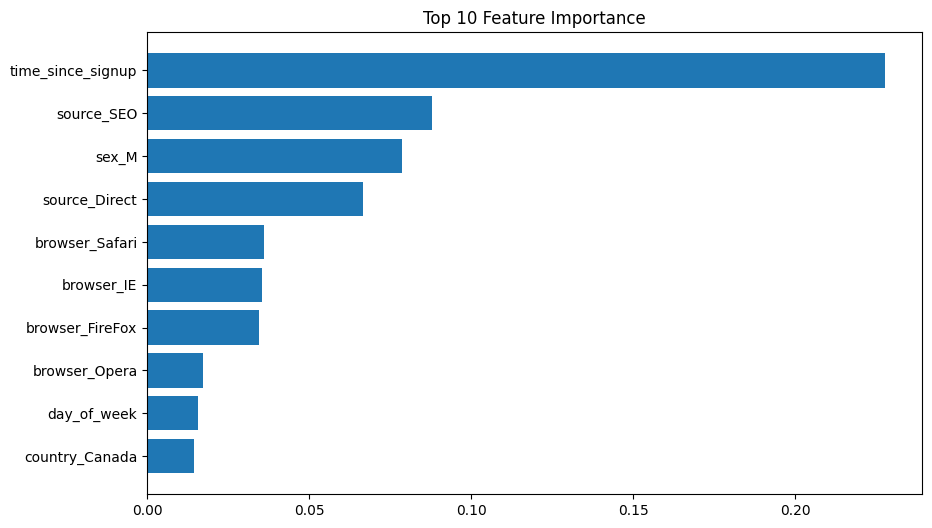

In [7]:


importance = (
    get_feature_importance(
        model,
        X_train.columns
    )
)

display(
    importance
)

plot_feature_importance(
    importance
)




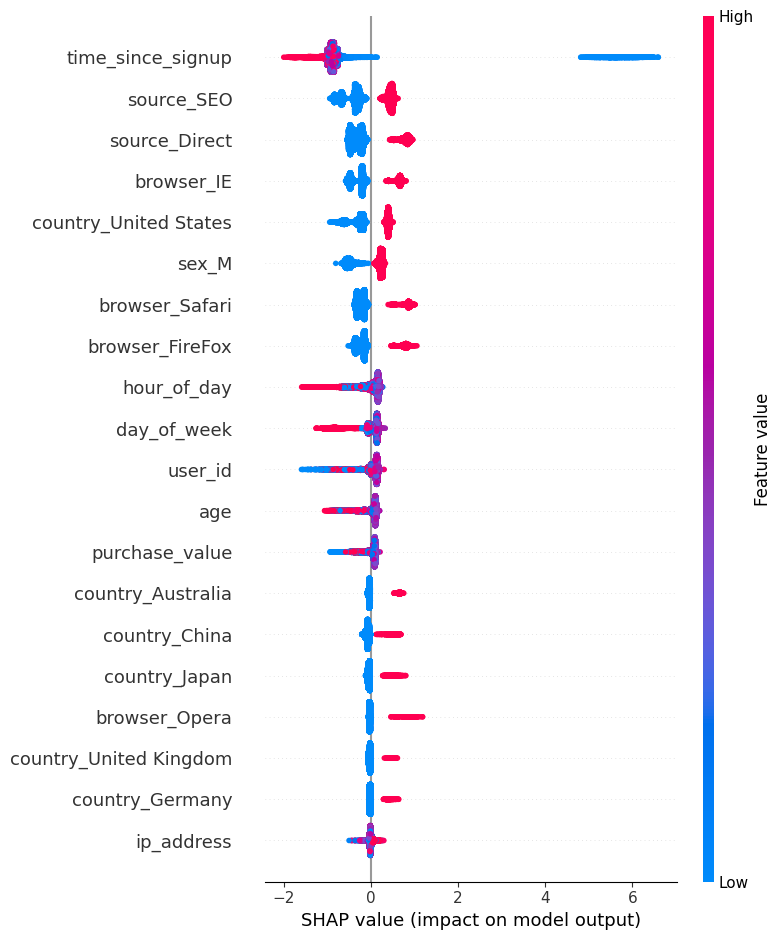

In [8]:


explainer, shap_values = (
    generate_shap_values(
        model,
        X_train,
        X_test
    )
)

plot_summary(
    shap_values,
    X_test
)




In [9]:


pred = (
    model.predict(
        X_test
    )
)

results = pd.DataFrame({

"actual":
y_test.values,

"pred":
pred

})




In [10]:


tp = results[
(results.actual==1)
&
(results.pred==1)
].index[0]

force_plot(
    explainer,
    shap_values,
    X_test,
    tp
)




In [11]:

fp = results[
(results.actual==0)
&
(results.pred==1)
].index[0]

force_plot(
    explainer,
    shap_values,
    X_test,
    fp
)




In [12]:

fn = results[
(results.actual==1)
&
(results.pred==0)
].index[0]

force_plot(
    explainer,
    shap_values,
    X_test,
    fn
)